In [33]:
import pickle
import numpy as np

# --- Path to your pickle file ---
# pkl_path = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=0\multiscale\2_10_norm_avgmean\multiscale\2_10_norm_avgmean--25-10-28-14-24-25\test_results.pkl"
pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_patient_allcat\multiscale\2_5_patient_allcat--25-10-30-15-21-25\test_results.pkl'
# --- Load pickle ---
with open(pkl_path, "rb") as f:
    results = pickle.load(f)

# --- Extract fields ---
labels = np.array(results["labels"])
probs = np.array(results["probs"])
slide_ids = np.array(results["sample_ids"])

# --- Predicted class (argmax over class probs) ---
preds = probs.argmax(axis=1)

# --- Identify misclassified indices ---
mis_idx = np.where(preds != labels)[0]
misclassified_slides = slide_ids[mis_idx]

# --- Print summary ---
print(f"Total samples: {len(slide_ids)}")
print(f"Misclassified: {len(misclassified_slides)} ({len(misclassified_slides)/len(slide_ids):.1%})\n")

print("Misclassified slides:")
for sid in misclassified_slides:
    print(" -", sid)


Total samples: 29
Misclassified: 7 (24.1%)

Misclassified slides:
 - FA_103
 - FA_108
 - FA_76
 - PT_40
 - PT_57
 - PT_93
 - PT_97


Found 9 matching files:

 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\210_run2_patient_allcat\multiscale\210_run2_patient_allcat--25-10-31-00-05-23\test_results.pkl
 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_10_patient_ABMIL\multiscale\2_10_patient_ABMIL--25-10-28-23-30-59\test_results.pkl
 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_10_patient_allcat\multiscale\2_10_patient_allcat--25-10-28-20-21-43\test_results.pkl
 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_norm_patient_avgmean\multiscale\2_5_norm_patient_avgmean--25-10-31-01-53-39\test_results.pkl
 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_patient_ABMIL\multiscale\2_5_patient_ABMIL--25-11-02-13-11-51\test_results.pkl
 - C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_patient_allcat\multiscale\2_5_patient_

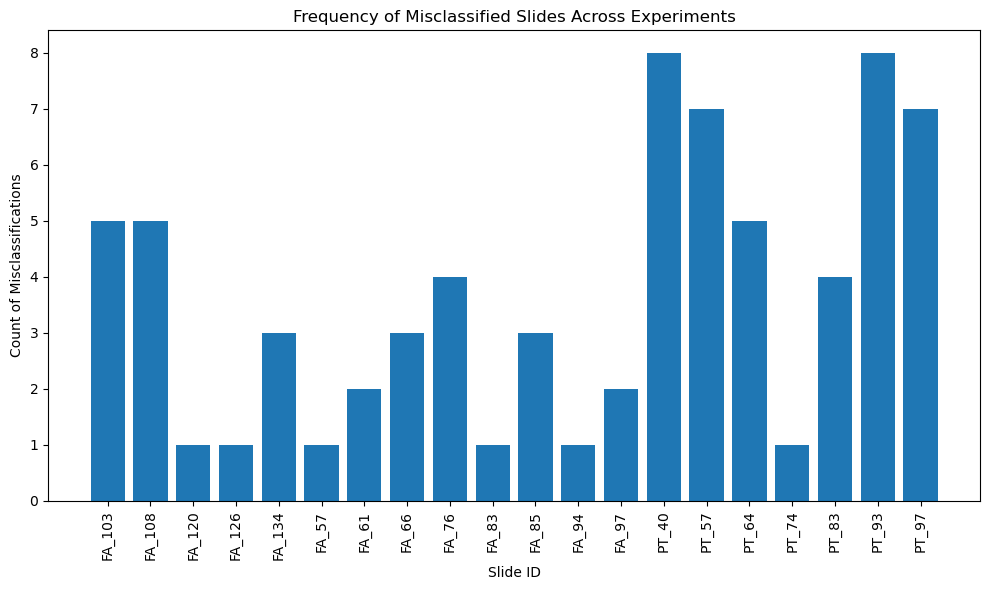

: 

In [ ]:
import os
import pickle
import numpy as np

# --- Root directory to search ---
root_dir = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale'

# --- Collect all .pkl files in 'patient' directories ---
pkl_paths = []
for dirpath, dirnames, filenames in os.walk(root_dir):
    if 'patient' in dirpath.lower():
        for fname in filenames:
            if fname == 'test_results.pkl':
                pkl_paths.append(os.path.join(dirpath, fname))

if not pkl_paths:
    print("No test_results.pkl files found under directories with 'patient' in the name.")
else:
    print(f"Found {len(pkl_paths)} matching files:\n")
    for p in pkl_paths:
        print(" -", p)
    print("\n")

# --- Iterate through found pkl files ---
all_misclassified = []

for pkl_path in pkl_paths:
    try:
        with open(pkl_path, "rb") as f:
            results = pickle.load(f)

        labels = np.array(results["labels"])
        probs = np.array(results["probs"])
        slide_ids = np.array(results["sample_ids"])
        preds = probs.argmax(axis=1)

        mis_idx = np.where(preds != labels)[0]
        misclassified_slides = slide_ids[mis_idx]

        print("=" * 100)
        print(f"[{os.path.basename(os.path.dirname(pkl_path))}]")
        print(f"Path: {pkl_path}")
        print(f"Total samples: {len(slide_ids)}")
        print(f"Misclassified: {len(misclassified_slides)} ({len(misclassified_slides)/len(slide_ids):.1%})")

        for sid in misclassified_slides:
            print(" -", sid)

        # Store for aggregate analysis
        all_misclassified.extend(list(misclassified_slides))

    except Exception as e:
        print(f"[ERROR] Failed to process {pkl_path}: {e}")

# --- Optional: aggregate summary ---
if all_misclassified:
    print("\n" + "=" * 100)
    print("Aggregated Misclassified Slides Across All Files:")
    unique, counts = np.unique(all_misclassified, return_counts=True)
    for sid, cnt in zip(unique, counts):
        print(f"{sid}: {cnt} times")
else:
    print("No misclassified samples found.")

import matplotlib.pyplot as plt
import numpy as np

# Only run this after running your previous code block
if all_misclassified:
    unique, counts = np.unique(all_misclassified, return_counts=True)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(unique)), counts)
    plt.xticks(range(len(unique)), unique, rotation=90)
    plt.xlabel("Slide ID")
    plt.ylabel("Count of Misclassifications")
    plt.title("Frequency of Misclassified Slides Across Experiments")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified slides to plot.")


In [ ]:
# read pkl file
pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=0\multiscale\2_10_patient_allcat\multiscale\2_10_patient_allcat--25-10-28-18-34-01\test_results.pkl'
with open(pkl_path, 'rb') as f:
    test_results = pickle.load(f)
labels = test_results['labels']
probs = test_results['probs']
slide_ids = test_results['sample_ids']  
print(f"Number of slides: {len(np.unique(slide_ids))}")

print(f"Labels: {labels}")
print(f"Slide IDs: {slide_ids}")
print(f"Probs: {probs}")

In [9]:
# read pkl file
pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_norm_patient_avgmean\multiscale\2_5_norm_patient_avgmean--25-10-31-01-53-39\test_results.pkl'
with open(pkl_path, 'rb') as f:
    test_results = pickle.load(f)
labels = test_results['labels']
probs = test_results['probs']
slide_ids = test_results['sample_ids']
# count number of slides
num_slides = len(np.unique(slide_ids))
print(f"Number of slides: {num_slides}")

print(f"Labels: {labels}")
print(f"Slide IDs: {slide_ids}")
print(f"Probs: {probs}")

Number of slides: 29
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
Slide IDs: ['FA_103' 'FA_108' 'FA_113' 'FA_117' 'FA_120' 'FA_126' 'FA_134' 'FA_57'
 'FA_61' 'FA_66' 'FA_69' 'FA_76' 'FA_83' 'FA_85' 'FA_94' 'FA_97' 'PT_36'
 'PT_40' 'PT_49' 'PT_53' 'PT_57' 'PT_64' 'PT_67' 'PT_74' 'PT_78' 'PT_83'
 'PT_89' 'PT_93' 'PT_97']
Probs: [[0.48224548 0.5177545 ]
 [0.45898947 0.54101056]
 [0.76360345 0.23639652]
 [0.6860781  0.3139219 ]
 [0.68957525 0.31042475]
 [0.76654017 0.23345982]
 [0.6627333  0.3372667 ]
 [0.5076678  0.4923322 ]
 [0.74579525 0.25420475]
 [0.60917217 0.39082786]
 [0.7688981  0.23110186]
 [0.6895123  0.31048772]
 [0.5902146  0.40978542]
 [0.7390782  0.2609218 ]
 [0.76620907 0.23379089]
 [0.5489358  0.4510642 ]
 [0.2273695  0.7726305 ]
 [0.53473467 0.46526533]
 [0.16337022 0.83662975]
 [0.39535838 0.6046416 ]
 [0.5894582  0.41054183]
 [0.5556131  0.44438693]
 [0.21946533 0.78053474]
 [0.49257645 0.5074235 ]
 [0.22584575 0.7741542 ]
 [0.52316344 0.47683656]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# --- Load the results ---
# pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=0\multiscale\2_10_norm_avgmean\multiscale\2_10_norm_avgmean--25-10-28-14-24-25\test_results.pkl'
pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=0\multiscale\2_10_norm_allcat\multiscale\2_10_norm_allcat--25-10-28-14-36-43\test_results.pkl'
with open(pkl_path, 'rb') as f:
    test_results = pickle.load(f)

labels = np.array(test_results['labels'])
probs = np.array(test_results['probs'])  # shape (N, 2)
slide_ids = np.array(test_results['sample_ids'])

# --- Extract probability for class 1 (PT) ---
pt_probs = probs[:, 1]

# --- Plot histograms for FA and PT ---
plt.figure(figsize=(6, 4))
plt.hist(
    pt_probs[labels == 0], bins=10, alpha=0.6,
    color='skyblue', edgecolor='black', label='FA (true 0)'
)
plt.hist(
    pt_probs[labels == 1], bins=10, alpha=0.6,
    color='limegreen', edgecolor='black', label='PT (true 1)'
)
plt.axvline(0.5, color='k', linestyle='--')
plt.xlabel('Predicted p(PT)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pickle
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, balanced_accuracy_score

# --- Load saved predictions ---
pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\2_5_norm_patient_avgmean\multiscale\2_5_norm_patient_avgmean--25-10-31-01-53-39\test_results.pkl'
# pkl_path = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=1\multiscale\2_10_allcat\multiscale\2_10_allcat--25-10-27-14-11-58\test_results.pkl'
with open(pkl_path, 'rb') as f:
    test_results = pickle.load(f)

labels = np.array(test_results['labels'])
probs = np.array(test_results['probs'])[:, 1]  # PT probabilities

# --- Evaluate over thresholds ---
thresholds = np.linspace(0, 1, 101)
accs, f1s, baccs = [], [], []

for t in thresholds:
    preds = (probs >= t).astype(int)
    accs.append(accuracy_score(labels, preds))
    f1s.append(f1_score(labels, preds))
    baccs.append(balanced_accuracy_score(labels, preds))

best_acc_t = thresholds[np.argmax(accs)]
best_f1_t = thresholds[np.argmax(f1s)]
best_bacc_t = thresholds[np.argmax(baccs)]

print(f"Best accuracy: {max(accs):.3f} @ threshold {best_acc_t:.2f}")
print(f"Best F1:       {max(f1s):.3f} @ threshold {best_f1_t:.2f}")
print(f"Best BAcc:     {max(baccs):.3f} @ threshold {best_bacc_t:.2f}")

# --- Always threshold-independent ---
auc = roc_auc_score(labels, probs)
print(f"AUC: {auc:.3f}")


Best accuracy: 0.862 @ threshold 0.41
Best F1:       0.867 @ threshold 0.41
Best BAcc:     0.875 @ threshold 0.41
AUC: 0.904


In [ ]:
import matplotlib.pyplot as plt

plt.plot(thresholds, accs, label='Accuracy')
plt.plot(thresholds, f1s, label='F1')
plt.plot(thresholds, baccs, label='Balanced Acc')
plt.axvline(0.5, color='k', linestyle='--', label='Default 0.5')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.legend()
plt.show()


adding column to split csv

In [40]:
import os
import re
import pandas as pd

def infer_case_id(slide_id: str) -> str:
    """
    Extracts case_id from slide_id.
    Examples:
      'FA 59 B1'  -> 'FA_59'
      'FA 59B'    -> 'FA_59'
      'PT 103 B2' -> 'PT_103'
    """
    # Normalize spacing (e.g., 'FA 59B' → 'FA 59 B')
    slide_id = re.sub(r'([0-9])([A-Za-z])', r'\1 \2', slide_id.strip())

    # Match prefix (FA/PT/anything letters) + digits
    match = re.match(r"([A-Za-z]+)\s*([0-9]+)", slide_id)
    if match:
        prefix, num = match.group(1), match.group(2)
        case_id = f"{prefix}_{num}"
    else:
        # Fallback: replace spaces for safety
        case_id = slide_id.replace(" ", "_")
    return case_id

# def add_case_column(csv_path, out_dir):
#     df = pd.read_csv(csv_path, header=None, names=["slide_id", "label"])
#     df["case_id"] = df["slide_id"].apply(infer_case_id)
#     df = df[["case_id", "slide_id", "label"]]  # reorder columns

#     fname = os.path.basename(csv_path)
#     out_path = os.path.join(out_dir, fname)
#     df.to_csv(out_path, index=False)
#     print(f"[✔] Saved: {out_path}")
#     return df

def add_case_column(csv_path, out_dir):
    # Try to detect header automatically
    df_preview = pd.read_csv(csv_path, nrows=1)
    if "slide_id" in df_preview.columns or "label" in df_preview.columns:
        df = pd.read_csv(csv_path)  # header exists
    else:
        df = pd.read_csv(csv_path, header=None, names=["slide_id", "label"])

    # Add case_id column
    df["case_id"] = df["slide_id"].apply(infer_case_id)
    df = df[["case_id", "slide_id", "label"]]

    # Save clean CSV (no index)
    fname = os.path.basename(csv_path)
    out_path = os.path.join(out_dir, fname)
    df.to_csv(out_path, index=False)
    print(f"[✔] Saved: {out_path}")
    return df

# === Run ===
train_csv = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\multiscale\210\FA_PT_k=4\train.csv"
val_csv   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\multiscale\210\FA_PT_k=4\val.csv"
test_csv  = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\multiscale\210\FA_PT_k=4\test.csv"
out_dir   = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\caseid_splits\k=4"

os.makedirs(out_dir, exist_ok=True)

for split, csv_path in zip(["train", "val", "test"], [train_csv, val_csv, test_csv]):
    df = add_case_column(csv_path, out_dir)


[✔] Saved: C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\caseid_splits\k=4\train.csv
[✔] Saved: C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\caseid_splits\k=4\val.csv
[✔] Saved: C:\Users\Vivian\Documents\PANTHER\PANTHER\src\splits\caseid_splits\k=4\test.csv


Calculating patient-level test metrics 

In [ ]:
import os, glob, pickle
from typing import Optional
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

ROOT = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt"
FOLDS = [f"k={i}" for i in range(5)]
RESULT_FILENAME = "test_results.pkl"

def find_test_pkl_for_fold(fold_dir: str) -> Optional[str]:
    # 1) find all test_results.pkl recursively
    pattern = os.path.join(fold_dir, "**", RESULT_FILENAME)
    all_hits = glob.glob(pattern, recursive=True)
    if not all_hits:
        return None
    # 2) prefer paths that mention '5x_norm_avgmean' (if present), else use all hits
    all_hits_norm = [p.replace("\\", "/") for p in all_hits]
    hits_pref = [p for p in all_hits_norm if "2_10_norm_avgmean" in p.lower()]
    hits = hits_pref if hits_pref else all_hits_norm

    SEGMENT = "5x_norm_avgmean"
    def path_has_segment(p, seg=SEGMENT):
        parts = p.replace("\\", "/").split("/")
        return any(part.lower() == seg.lower() for part in parts)
    prefer = [p for p in hits if path_has_segment(p)]
    return prefer[0] if prefer else hits[0]

    
def patient_id_from_slide(slide_id: str) -> str:
    parts = slide_id.split()
    return " ".join(parts[:2]) if len(parts) >= 2 else slide_id

def load_results(pkl_path: str):
    with open(pkl_path, "rb") as f:
        res = pickle.load(f)
    return np.asarray(res["labels"]), np.asarray(res["probs"]), np.asarray(res["sample_ids"])

def patient_level_metrics(labels, probs, slide_ids):
    df = pd.DataFrame({
        "slide_id": slide_ids,
        "patient": [patient_id_from_slide(s) for s in slide_ids],
        "label": labels.astype(int),
        "prob_pt": probs[:, 1],
    })
    g = df.groupby("patient", as_index=False).agg(
        label=("label", "first"),
        prob_pt=("prob_pt", "mean"),
        n_slides=("slide_id", "count"),
    )
    g["pred"] = (g["prob_pt"] >= 0.5).astype(int)
    y_true, y_prob, y_pred = g["label"].to_numpy(), g["prob_pt"].to_numpy(), g["pred"].to_numpy()
    acc = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    f1w = f1_score(y_true, y_pred, average="weighted")
    return acc, auc, f1w, g

def main():
    rows, fold_tables = [], {}
    for fold in FOLDS:
        fold_dir = os.path.join(ROOT, fold)
        pkl_path = find_test_pkl_for_fold(fold_dir)
        if not pkl_path:
            print(f"[WARN] No {RESULT_FILENAME} found under {fold_dir}")
            continue
        print(f"[FOUND] {fold}: {pkl_path}")

        labels, probs, slides = load_results(pkl_path)
        acc, auc, f1w, g = patient_level_metrics(labels, probs, slides)
        rows.append({"fold": fold, "acc": acc, "auc": auc, "f1": f1w, "n_patients": len(g), "pkl": pkl_path})
        fold_tables[fold] = g

    if not rows:
        print("No folds processed.")
        return

    df = pd.DataFrame(rows).set_index("fold")
    print("\nPer-fold patient-level metrics:")
    print(df[["acc", "auc", "f1", "n_patients"]].round(3))

    summary = {
        "acc_mean": float(np.nanmean(df["acc"])), "acc_std": float(np.nanstd(df["acc"], ddof=0)),
        "auc_mean": float(np.nanmean(df["auc"])), "auc_std": float(np.nanstd(df["auc"], ddof=0)),
        "f1_mean":  float(np.nanmean(df["f1"])),  "f1_std":  float(np.nanstd(df["f1"], ddof=0)),
    }
    print("\n5-fold patient-level summary (mean ± std):")
    print(f"Accuracy: {summary['acc_mean']:.3f} ± {summary['acc_std']:.3f}")
    print(f"AUC:      {summary['auc_mean']:.3f} ± {summary['auc_std']:.3f}")
    print(f"F1:       {summary['f1_mean']:.3f} ± {summary['f1_std']:.3f}")

    # out_dir = os.path.join(ROOT, "patient_sum", '2.5x_5x_allcat')
    # os.makedirs(out_dir, exist_ok=True)
    # df.to_csv(os.path.join(out_dir, "fold_metrics.csv"))
    # for fold, tab in fold_tables.items():
    #     tab.to_csv(os.path.join(out_dir, f"{fold}_patients.csv"), index=False)
    # print(f"\nSaved: {out_dir}")

if __name__ == "__main__":
    main()


calculate mean metrics across folds

In [30]:
from pathlib import Path
import csv
import statistics as stats
from dataclasses import dataclass
from typing import List, Optional, Tuple

# --- configuration ---
root = Path(r"C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt")
# exp_name = "2_10_patient_ABMIL"  # folder name to look for (e.g. inside each k=*)
exp_name = 'multiscale/52_patient_avgmean'

# --- helper data structure ---
@dataclass
class FoldResult:
    fold: str
    acc: float
    auc: float
    f1: float
    csv_path: Path

HEADERS = {
    "acc": "acc_test",
    "auc": "roc_auc_test",
    "f1": "weighted_f1_test",
}

def find_latest_summary(k_dir: Path, exp_name: str) -> Optional[Path]:
    """Find the most recent summary.csv under the experiment folder within a given fold."""
    candidates = list(k_dir.rglob(f"{exp_name}"))
    csvs = []
    for d in candidates:
        csvs.extend(d.rglob("summary.csv"))
    if not csvs:
        return None
    csvs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return csvs[0]

def read_metrics_from_summary(csv_path: Path) -> Tuple[float, float, float]:
    """Extract acc_test, roc_auc_test, and weighted_f1_test from summary.csv."""
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        row = next(reader, None)
        if row is None:
            raise ValueError(f"{csv_path} is empty or malformed.")
        return (
            float(row[HEADERS["acc"]]),
            float(row[HEADERS["auc"]]),
            float(row[HEADERS["f1"]]),
        )

def round3(x: float) -> float:
    return float(f"{x:.3f}")

# --- main logic ---
results: List[FoldResult] = []
missing = []

k_dirs = sorted([p for p in root.glob("k=*") if p.is_dir()], key=lambda p: p.name)
if not k_dirs:
    print(f"No fold directories found under {root}")
else:
    for k_dir in k_dirs:
        csv_path = find_latest_summary(k_dir, exp_name)
        if csv_path is None:
            missing.append(k_dir)
            continue
        try:
            acc, auc, f1 = read_metrics_from_summary(csv_path)
            results.append(FoldResult(fold=k_dir.name, acc=acc, auc=auc, f1=f1, csv_path=csv_path))
        except Exception as e:
            print(f"[WARN] Skipping {k_dir}: {e}")

# --- display per-fold results ---
if results:
    print("Per-fold test metrics (rounded to 3 decimals):")
    print("fold,acc_test,auc_test,f1_test,csv_path")
    for r in results:
        print(f"{r.fold},{round3(r.acc)},{round3(r.auc)},{round3(r.f1)},{r.csv_path}")

    # mean ± std
    accs = [r.acc for r in results]
    aucs = [r.auc for r in results]
    f1s  = [r.f1  for r in results]

    def mean_std(x: List[float]):
        mean = stats.mean(x)
        std  = stats.pstdev(x) if len(x) > 1 else 0.0
        return round3(mean), round3(std)

    acc_mean, acc_std = mean_std(accs)
    auc_mean, auc_std = mean_std(aucs)
    f1_mean,  f1_std  = mean_std(f1s)

    print("\nAggregate (mean ± std):")
    print(f"ACC: {acc_mean} ± {acc_std}")
    print(f"AUC: {auc_mean} ± {auc_std}")
    print(f"F1 : {f1_mean} ± {f1_std}")

if missing:
    print("\nMissing summary.csv for:")
    for d in missing:
        print(f"- {d}")


Per-fold test metrics (rounded to 3 decimals):
fold,acc_test,auc_test,f1_test,csv_path
k=0,0.483,0.63,0.392,C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=0\multiscale\52_patient_avgmean\multiscale\52_patient_avgmean--25-11-04-02-15-13\summary.csv
k=1,0.552,0.678,0.473,C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=1\multiscale\52_patient_avgmean\multiscale\52_patient_avgmean--25-11-04-02-24-32\summary.csv
k=2,0.517,0.514,0.449,C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=2\multiscale\52_patient_avgmean\multiscale\52_patient_avgmean--25-11-04-02-33-49\summary.csv
k=3,0.552,0.714,0.473,C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=3\multiscale\52_patient_avgmean\multiscale\52_patient_avgmean--25-11-04-02-43-07\summary.csv
k=4,0.414,0.536,0.262,C:\Users\Vivian\Documents\PANTHER\PANTHER\src\results\fa_vs_pt\k=4\multiscale\52_patient_avgmean\multiscale\52_patient_avgmean--25-11-04-02-52-24\summary.csv

Aggregate (me

In [2]:
# # load pt files and compare tensors
# import torch
# pt_a = torch.load(r"C:\Users\Vivian\Documents\dsmil-wsi\temp_train_2_5\FA 47 B1.pt")
# pt_b = torch.load(r"C:\Users\Vivian\Documents\dsmil-wsi\temp_train2_10\FA 47 B1.pt")

# print(pt_a.shape)
# print(pt_b.shape)

import torch
import hashlib

# path_a = r"C:\Users\Vivian\Documents\dsmil-wsi\temp_train_2_5\FA 47 B1.pt"
# path_b = r"C:\Users\Vivian\Documents\dsmil-wsi\temp_train2_10\FA 47 B1.pt"

# path_a = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\210\uniextracted_mag210x_patch224_fp\feats_pt\FA 47 B1.pt'
path_a = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag25x_patch224_fp\feats_pt\FA 47 B1.pt'
path_b = r'C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag210x_patch224_fp\feats_pt\FA 47 B1.pt'
# --- 1. Quick byte-level comparison (identical files) ---
def md5sum(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

hash_a, hash_b = md5sum(path_a), md5sum(path_b)
print("MD5 equal?", hash_a == hash_b)

# --- 2. Compare tensor contents numerically ---
t1 = torch.load(path_a, map_location="cpu")
t2 = torch.load(path_b, map_location="cpu")

# optional: handle dict or list containers
if isinstance(t1, dict) and "features" in t1:
    t1, t2 = t1["features"], t2["features"]

print("Shape equal?", t1.shape == t2.shape)

# if same shape, compute difference stats
if t1.shape == t2.shape:
    diff = (t1 - t2).abs()
    print("Max abs diff:", diff.max().item())
    print("Mean abs diff:", diff.mean().item())
    print("Allclose?", torch.allclose(t1, t2, atol=1e-6))



MD5 equal? True
Shape equal? True
Max abs diff: 0.0
Mean abs diff: 0.0
Allclose? True


In [14]:
# from pathlib import Path
# import hashlib
# import pandas as pd



# csv_a = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag25x_patch224_fp\feats_h5\FA 47 B1.h5"
# csv_b = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag210x_patch224_fp\feats_h5\FA 47 B1.h5"
import h5py
import numpy as np
import hashlib

# path_a = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag25x_patch224_fp\feats_h5\FA 47 B1.h5"
path_a = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_h5\FA 47 B1.h5"
path_b = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_h5_5x_aligned\FA 47 B1.h5"

# --- 1. Quick byte-level comparison (raw file identical?) ---
def md5sum(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

hash_a, hash_b = md5sum(path_a), md5sum(path_b)
print("MD5 equal?", hash_a == hash_b)

# --- 2. Compare dataset contents numerically ---
def compare_h5(f1_path, f2_path, atol=1e-6):
    diffs = {}
    with h5py.File(f1_path, "r") as f1, h5py.File(f2_path, "r") as f2:
        keys1, keys2 = set(f1.keys()), set(f2.keys())
        print("Keys A:", keys1)
        print("Keys B:", keys2)

        common_keys = keys1 & keys2
        for key in common_keys:
            arr1 = np.array(f1[key])
            arr2 = np.array(f2[key])

            if arr1.shape != arr2.shape:
                diffs[key] = f"Different shapes: {arr1.shape} vs {arr2.shape}"
                continue

            same = np.allclose(arr1, arr2, atol=atol)
            if same:
                diffs[key] = "All values close"
            else:
                diffs[key] = {
                    "shape": arr1.shape,
                    "max_abs_diff": float(np.max(np.abs(arr1 - arr2))),
                    "mean_abs_diff": float(np.mean(np.abs(arr1 - arr2))),
                }

        missing_a = keys1 - keys2
        missing_b = keys2 - keys1
        if missing_a:
            diffs["missing_in_B"] = list(missing_a)
        if missing_b:
            diffs["missing_in_A"] = list(missing_b)
    return diffs

diffs = compare_h5(path_a, path_b)
print("\nComparison summary:")
for k, v in diffs.items():
    print(f"{k}: {v}")


MD5 equal? False
Keys A: {'features', 'coords'}
Keys B: {'features', 'coords'}

Comparison summary:
features: All values close
coords: {'shape': (2135, 2), 'max_abs_diff': 13440.0, 'mean_abs_diff': 3048.2360655737707}


In [17]:
import torch, h5py, numpy as np

# === EDIT THESE PATHS ===
pt_path = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_pt\FA 47 B1.pt"
h5_path = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_h5\FA 47 B1.h5"
# =========================

# ---- Load features from .pt ----
pt_obj = torch.load(pt_path, map_location="cpu")
if isinstance(pt_obj, dict) and "features" in pt_obj:
    feats_pt = pt_obj["features"].cpu().numpy()
else:
    feats_pt = pt_obj.cpu().numpy()
print(f"PT features: {feats_pt.shape}")

# ---- Load features from .h5 ----
with h5py.File(h5_path, "r") as f:
    feats_h5 = np.array(f["features"])
print(f"H5 features: {feats_h5.shape}")

# ---- Compare ----
same_shape = feats_pt.shape == feats_h5.shape
all_close  = np.allclose(feats_pt, feats_h5, atol=1e-6)
max_diff   = np.max(np.abs(feats_pt - feats_h5)) if same_shape else None

print(f"Shape equal? {same_shape}")
if same_shape:
    print(f"All values close? {all_close}")
    print(f"Max absolute difference: {max_diff:.6g}")
else:
    print("Cannot compare — feature shapes differ.")


PT features: (2135, 2048)
H5 features: (2135, 2048)
Shape equal? True
All values close? True
Max absolute difference: 0


checking coords between h5 files

In [18]:
import h5py
import numpy as np

# === Paths to your H5s ===
path_a = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_h5\FA 47 B1.h5"
path_b = r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\52\uniextracted_mag52x_patch224_fp\feats_h5_5x_aligned\FA 47 B1.h5"

# --- Load coords ---
def load_coords(h5_path):
    with h5py.File(h5_path, "r") as f:
        coords = np.array(f["coords"])
    return coords

coords_a = load_coords(path_a)
coords_b = load_coords(path_b)

print(f"A coords shape: {coords_a.shape}, B coords shape: {coords_b.shape}")

# --- Quick shape + equality check ---
same_shape = coords_a.shape == coords_b.shape
all_equal = np.array_equal(coords_a, coords_b)
print(f"Shape equal? {same_shape}")
print(f"All values exactly equal? {all_equal}")

# --- If shapes match but values differ, measure how much ---
if same_shape and not all_equal:
    diff = coords_a - coords_b
    max_diff = np.abs(diff).max(axis=0)
    mean_diff = np.abs(diff).mean(axis=0)
    n_diff = np.count_nonzero(np.any(diff != 0, axis=1))
    print(f"\nNon-identical coordinates: {n_diff} / {coords_a.shape[0]}")
    print(f"Mean absolute diff (x,y): {mean_diff}")
    print(f"Max absolute diff (x,y): {max_diff}")

    # Optionally show first few mismatched rows
    mism_idx = np.where(np.any(diff != 0, axis=1))[0][:10]
    print("\nFirst mismatched indices and values:")
    for i in mism_idx:
        print(f"{i:5d} | A={coords_a[i]}  B={coords_b[i]}  Δ={diff[i]}")

# --- If shapes differ ---
elif not same_shape:
    print("\nDifferent shapes → cannot align directly.")
    print(f"Unique A coords: {len(np.unique(coords_a, axis=0))}, Unique B coords: {len(np.unique(coords_b, axis=0))}")
    inter = len(np.intersect1d(coords_a.view([('', coords_a.dtype)]*2),
                               coords_b.view([('', coords_b.dtype)]*2)))
    print(f"Approx. overlap count: {inter}")


A coords shape: (2135, 2), B coords shape: (2135, 2)
Shape equal? True
All values exactly equal? False

Non-identical coordinates: 2110 / 2135
Mean absolute diff (x,y): [3330.41311475 2766.05901639]
Max absolute diff (x,y): [13440 12544]

First mismatched indices and values:
    1 | A=[11200 10080]  B=[5600 4704]  Δ=[5600 5376]
    2 | A=[ 9632 10752]  B=[ 5600 10304]  Δ=[4032  448]
    3 | A=[11200  3136]  B=[10976  6944]  Δ=[  224 -3808]
    4 | A=[11872  8736]  B=[3360 7392]  Δ=[8512 1344]
    5 | A=[1344  448]  B=[5376 2016]  Δ=[-4032 -1568]
    6 | A=[11872  9856]  B=[5600 7392]  Δ=[6272 2464]
    7 | A=[1344  448]  B=[6272 2464]  Δ=[-4928 -2016]
    8 | A=[11872  2464]  B=[13888  4928]  Δ=[-2016 -2464]
    9 | A=[10080 12768]  B=[ 6944 11200]  Δ=[3136 1568]
   10 | A=[11200  3136]  B=[13440  8064]  Δ=[-2240 -4928]


In [ ]:
# read a numpy file and save as a png image
import numpy as np
import matplotlib.pyplot as plt
npy_path = r"C:\Users\Vivian\Documents\CONCH\all_patches\patches_5x\40x\PT\PT 74 B2\patch_848_x6720_y6496.npy"
arr = np.load(npy_path)
print(f"Array shape: {arr.shape}, dtype: {arr.dtype}")
plt.imshow(arr, cmap='gray')
plt.axis('off')
plt.show()
# save as png
png_path = npy_path.replace('.npy', '.png')
# plt.imsave(png_path, arr, cmap='gray')

plt.figure(figsize=(2,2), dpi=300)
plt.imshow(arr)
plt.axis('off')
plt.savefig(png_path, bbox_inches='tight', pad_inches=0, dpi=300)

